In [14]:
#1.Import Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
train_path = r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\DataSets\Sentiment analysis dataset\train.csv"
test_path  = r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\DataSets\Sentiment analysis dataset\test.csv"
train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)
print(train_df.columns)

Index(['id', 'sentiment', 'tweet'], dtype='object')


In [16]:
def preprocess(df):
    texts = df['tweet'].astype(str).str.lower()

    labels = df['sentiment'].astype(str).str.strip()

    # Mapping
    labels = labels.map({'Positive':1, 'Negative':0})

    # Combine into one DataFrame for safe filtering
    data = pd.DataFrame({'text': texts, 'label': labels})

    # REMOVE ALL NaN rows (VERY IMPORTANT)
    data = data.dropna()

    # Convert types properly
    texts = data['text'].tolist()
    labels = data['label'].astype(int).tolist()

    return texts, labels

In [17]:
train_texts, train_labels = preprocess(train_df)
test_texts, test_labels   = preprocess(test_df)

In [18]:

def build_vocab(texts, min_freq=1):
    counter = Counter()

    for text in texts:
        counter.update(text.split())

    vocab = {'<PAD>':0, '<UNK>':1}

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab

vocab = build_vocab(train_texts)

In [19]:
def load_glove(path):
    glove = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            glove[word] = vector
    return glove

glove_path = r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\glove.6B\glove.6B.200d.txt"
glove = load_glove(glove_path)

In [20]:
def create_embedding_matrix(vocab, glove, dim=200):
    matrix = np.zeros((len(vocab), dim))

    for word, idx in vocab.items():
        if word in glove:
            matrix[idx] = glove[word]
        else:
            matrix[idx] = np.random.normal(scale=0.6, size=(dim,))

    return torch.tensor(matrix, dtype=torch.float32)

embedding_matrix = create_embedding_matrix(vocab, glove)

In [21]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=100):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def encode(self, text):
        tokens = text.split()
        ids = [self.vocab.get(w, self.vocab['<UNK>']) for w in tokens]

        length = min(len(ids), self.max_len)

        if len(ids) < self.max_len:
            ids += [0]*(self.max_len - len(ids))
        else:
            ids = ids[:self.max_len]

        return ids, length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids, length = self.encode(self.texts[idx])
        return torch.tensor(ids), torch.tensor(length), torch.tensor(self.labels[idx], dtype=torch.long)
    
    
train_dataset = TextDataset(train_texts, train_labels, vocab)
test_dataset  = TextDataset(test_texts, test_labels, vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64)

In [22]:
class RNNModel(nn.Module):
    def __init__(self, embedding_matrix):
        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.rnn = nn.RNN(embed_dim, 25, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(25, 2)

    def forward(self, x, lengths):
        x = self.embedding(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_out, hidden = self.rnn(packed)

        out = hidden[-1]
        out = self.dropout(out)
        return self.fc(out)

In [23]:
def train(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, lengths, y in loader:
        optimizer.zero_grad()

        outputs = model(x, lengths)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss/len(loader), correct/total

In [24]:
def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, lengths, y in loader:
            outputs = model(x, lengths)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.numpy())
            all_labels.extend(y.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds)
    return cm, report

In [25]:
def detailed_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    # Negative class
    neg_correct = tn
    neg_wrong = fp
    neg_total = tn + fp
    neg_acc = neg_correct / neg_total if neg_total != 0 else 0

    # Positive class
    pos_correct = tp
    pos_wrong = fn
    pos_total = tp + fn
    pos_acc = pos_correct / pos_total if pos_total != 0 else 0

    # Overall
    total_correct = tn + tp
    total = tn + fp + fn + tp
    overall_acc = total_correct / total

    print("\n===== FINAL RESULTS =====")

    print("\nNegative Sentiment:")
    print(f"Correct Predictions: {neg_correct}")
    print(f"Wrong Predictions: {neg_wrong}")
    print(f"Accuracy: {100*neg_acc:.2f}%")

    print("\nPositive Sentiment:")
    print(f"Correct Predictions: {pos_correct}")
    print(f"Wrong Predictions: {pos_wrong}")
    print(f"Accuracy: {100*pos_acc:.2f}%")

    print("\nOverall Model Accuracy:")
    print(f"{100*overall_acc:.2f}%")
    

def plot_confusion_matrix(cm):
    plt.figure(figsize=(2,2))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

Epoch 1: Loss=0.5904, Accuracy=0.7439
Epoch 2: Loss=0.4483, Accuracy=0.9209
Epoch 3: Loss=0.4141, Accuracy=0.9307
Epoch 4: Loss=0.3786, Accuracy=0.9345
Epoch 5: Loss=0.3531, Accuracy=0.9300
Epoch 6: Loss=0.3184, Accuracy=0.9275
Epoch 7: Loss=0.2882, Accuracy=0.9373
Epoch 8: Loss=0.2716, Accuracy=0.9386
Epoch 9: Loss=0.2641, Accuracy=0.9386
Epoch 10: Loss=0.2433, Accuracy=0.9448
Epoch 11: Loss=0.2371, Accuracy=0.9430
Epoch 12: Loss=0.2243, Accuracy=0.9473
Epoch 13: Loss=0.2124, Accuracy=0.9495
Epoch 14: Loss=0.2102, Accuracy=0.9491
Epoch 15: Loss=0.1995, Accuracy=0.9534
Epoch 16: Loss=0.1897, Accuracy=0.9571
Epoch 17: Loss=0.1811, Accuracy=0.9593
Epoch 18: Loss=0.1748, Accuracy=0.9604
Epoch 19: Loss=0.1665, Accuracy=0.9630
Epoch 20: Loss=0.1693, Accuracy=0.9607
Epoch 21: Loss=0.1533, Accuracy=0.9652
Epoch 22: Loss=0.1486, Accuracy=0.9648
Epoch 23: Loss=0.1405, Accuracy=0.9675
Epoch 24: Loss=0.1344, Accuracy=0.9695
Epoch 25: Loss=0.1281, Accuracy=0.9736
Epoch 26: Loss=0.1271, Accuracy=0.

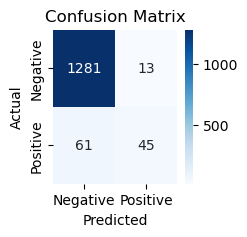

In [26]:
model = RNNModel(embedding_matrix)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_labels
)
class_weights = torch.tensor([1.0, 2.5], dtype=torch.float)

# Apply weights to loss
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
for epoch in range(30):
    loss, acc = train(model, train_loader, optimizer, criterion)
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")
    

    
cm, report = evaluate(model, test_loader)
detailed_metrics(cm)
plot_confusion_matrix(cm)